In [17]:
# importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


In [18]:
# Load the dataset 
df_processed = pd.read_csv('../data/heart_processed.csv')
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Apply PCA for dimensionality reduction
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(df_processed[num_cols])

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Explained Variance per PC:", explained_variance.tolist())
print("Cumulative Variance:", cumulative_variance.tolist())

Explained Variance per PC: [0.754616920183169, 0.14573046697688832, 0.08246833835960372]
Cumulative Variance: [0.754616920183169, 0.9003473871600572, 0.982815725519661]


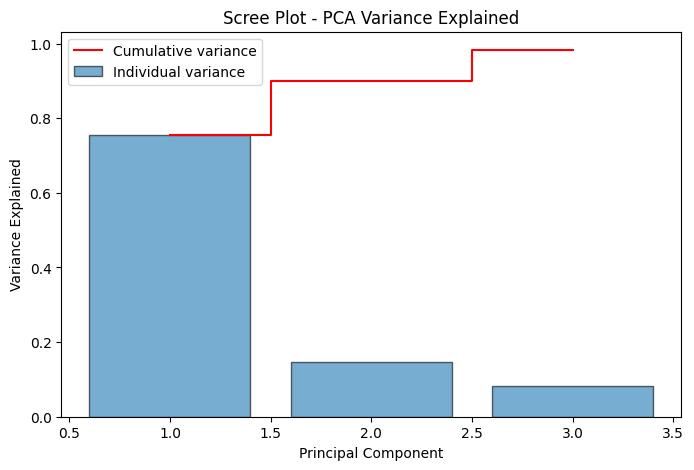

In [19]:
# 6.scree variance plot
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual variance',edgecolor='black')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', color='red', label='Cumulative variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot - PCA Variance Explained')
plt.legend()
plt.show()

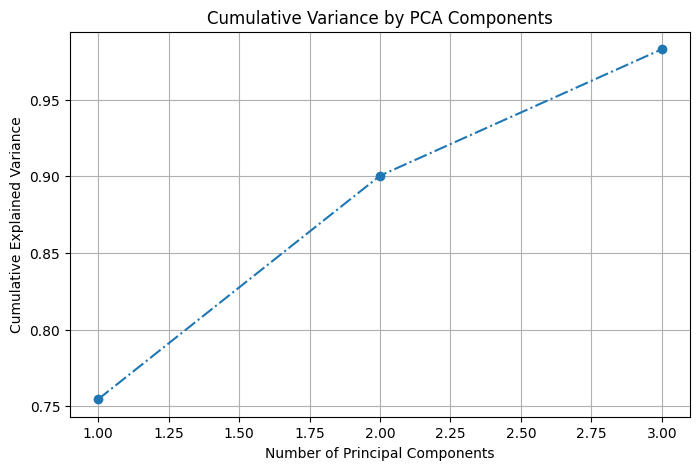

In [20]:
#cumulative variance plot
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-.')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance by PCA Components')
plt.grid(True)
plt.show()


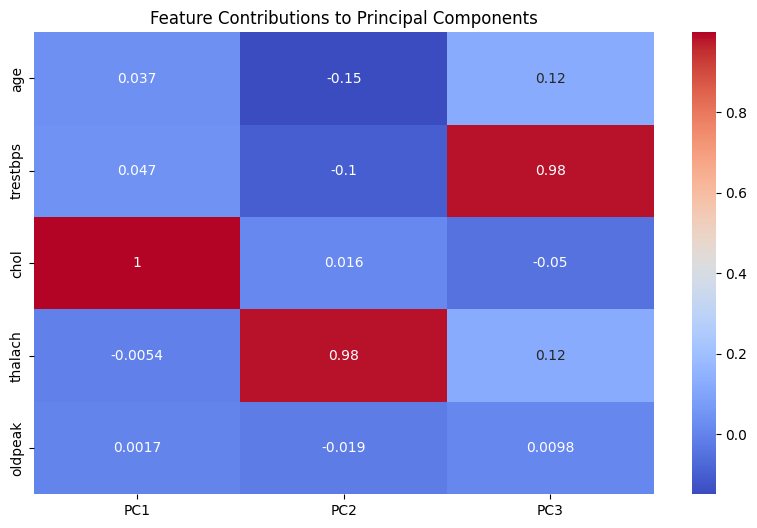

In [21]:
# heatmap between feature and pca component
loadings = pd.DataFrame(pca.components_.T, index=num_cols, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.title('Feature Contributions to Principal Components')
plt.show()
